# Volatility Simulations & Experiments

This notebook is essentially a refresher on my own knowledge of basic quantitative finance. It's based off some of the exercises in 'Paul Wilmott introduces Quantitative Finance, Second Edition.'

## Logarithmic random walk

This effect is achieved by either scaling either up by a percentage or down by the same percentage. For a small number of samples, the behaviour doesn't look very realistic, but the realism increases as we increase the number of samples.

Text(0, 0.5, 'y(t)')

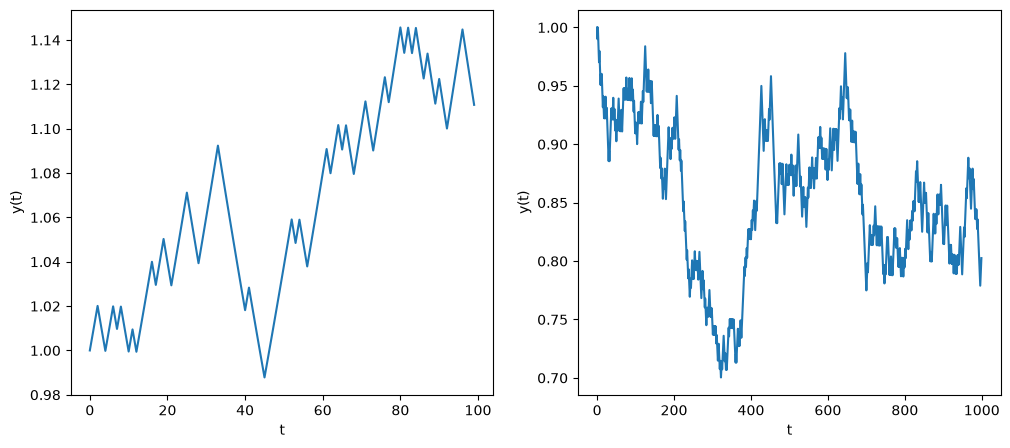

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

N = 100

def fill_samples(N, scale_factors=(0.99, 1.01), resample_interval=1):
    global t
    global y
    t = resample_interval * np.arange(N // resample_interval)
    y = np.zeros_like(t, dtype=float)
    y[0] = 1.0
    
    for i in range(1, len(y)):
        scale = scale_factors[0] if random.random() < 0.5 else scale_factors[1]
        y[i] = scale * y[i - 1]

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(12, 5)

fill_samples(100)
ax1.plot(t, y)
ax1.set_xlabel('t')
ax1.set_ylabel('y(t)')
fill_samples(1000)
ax2.plot(t, y)
ax2.set_xlabel('t')
ax2.set_ylabel('y(t)')

Ch. 2, p. 42 has an exercise to change some of the parameters of this procedure. We can change how often each 'step' is re-computed, and also by how much we scale on each step.

Since some of these plots can be hard to make sense of, we can compute the volatility as standard deviation of the residual between the function itself and a line from the first point to the last one.

Re-running this a few times, it looks one of the biggest factors in our measure of volatility is which direction the random walk takes as a whole. If there is a large hill, or otherwise a trend that deviates from the line, our measure of volatility increases. A general trend is that when we use the larger (and smaller) scale factors, this also increases volatility. This change is more likely due to the actual nature of the fluctuation of the function and not a general change of direction, which as we see biases the results.

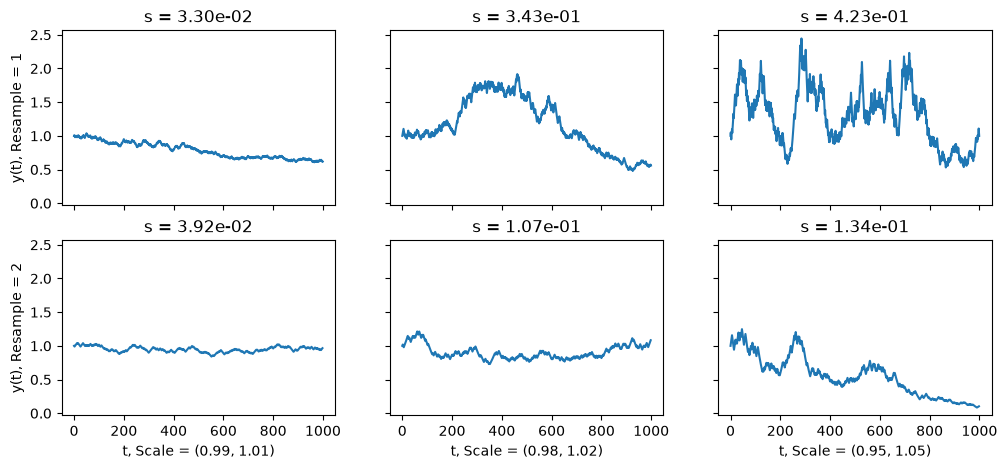

In [3]:
scale_factors = [
    (0.99, 1.01),
    (0.98, 1.02),
    (0.95, 1.05),
]
resample_intervals = [1, 2]

def linear_volatility(y):
    line = np.linspace(y[0], y[-1], len(y))
    return np.std(y - line)

fig, axes = plt.subplots(len(resample_intervals), len(scale_factors), sharex=True, sharey=True)
fig.set_size_inches(12, 5)

for yi, (row, resample_interval) in enumerate(zip(axes, resample_intervals)):
    for xi, (ax, scale_factor) in enumerate(zip(row, scale_factors)):
        fill_samples(1000, scale_factor, resample_interval)
        ax.plot(t, y)
        ax.set_title(f's = {linear_volatility(y):.2e}')
        if xi == 0:
            ax.set_ylabel(f'y(t), Resample = {resample_interval}')
        if yi == len(resample_intervals) - 1:
            ax.set_xlabel(f't, Scale = {scale_factor}')